<a href="https://colab.research.google.com/github/gunwes16/data201-project1-classification/blob/main/eda/notebooks/2.0-eda-summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
   import pandas as pd

   url = "https://raw.githubusercontent.com/gunwes16/data201-project1-classification/refs/heads/main/data/processed/bank-clean%20(2).csv"
   df = pd.read_csv(url)   # creates df; every later cell depends on it
   print(df.shape)         # expect (45211, 17)

(45211, 17)


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

def save_fig(name):
    """Save the current chart as a PNG and download it for eda/images/."""
    plt.savefig(name, dpi=120, bbox_inches="tight")
    files.download(name)

In [16]:
num_cols = ["age", "balance", "day", "campaign", "pdays", "previous"]
display(df[num_cols].describe().round(1))
display(df.groupby("y")[num_cols].median())

,age,balance,day,campaign,pdays,previous
count,45211.0,45211.0,45211.0,45211.0,45211.0,45211.0
mean,40.9,1362.3,15.8,2.8,40.2,0.6
std,10.6,3044.8,8.3,3.1,100.1,2.3
min,18.0,-8019.0,1.0,1.0,-1.0,0.0
25%,33.0,72.0,8.0,1.0,-1.0,0.0
50%,39.0,448.0,16.0,2.0,-1.0,0.0
75%,48.0,1428.0,21.0,3.0,-1.0,0.0
max,95.0,102127.0,31.0,63.0,871.0,275.0


,age,balance,day,campaign,pdays,previous
y,,,,,,
0,39.0,417.0,16.0,2.0,-1.0,0.0
1,38.0,733.0,15.0,2.0,-1.0,0.0


In [17]:
num_cols = ["age", "balance", "day", "campaign", "pdays", "previous"]
display(df[num_cols].describe().round(1))       # overall
display(df.groupby("y")[num_cols].median())      # medians: non-subscribers vs subscribers

,age,balance,day,campaign,pdays,previous
count,45211.0,45211.0,45211.0,45211.0,45211.0,45211.0
mean,40.9,1362.3,15.8,2.8,40.2,0.6
std,10.6,3044.8,8.3,3.1,100.1,2.3
min,18.0,-8019.0,1.0,1.0,-1.0,0.0
25%,33.0,72.0,8.0,1.0,-1.0,0.0
50%,39.0,448.0,16.0,2.0,-1.0,0.0
75%,48.0,1428.0,21.0,3.0,-1.0,0.0
max,95.0,102127.0,31.0,63.0,871.0,275.0


,age,balance,day,campaign,pdays,previous
y,,,,,,
0,39.0,417.0,16.0,2.0,-1.0,0.0
1,38.0,733.0,15.0,2.0,-1.0,0.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

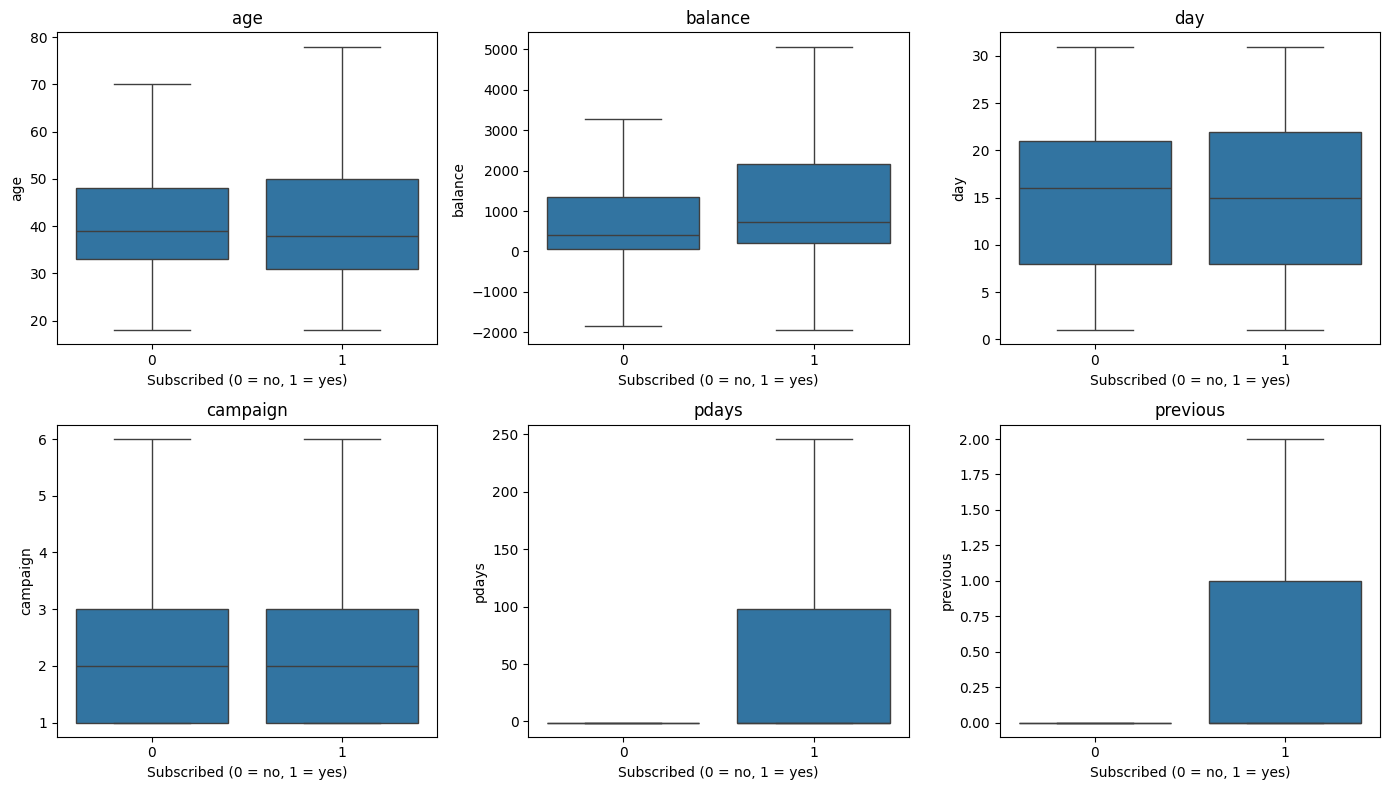

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x="y", y=col, ax=ax, showfliers=False)  # hide extreme outliers
    ax.set_title(col)
    ax.set_xlabel("Subscribed (0 = no, 1 = yes)")
plt.tight_layout()
save_fig("2.1-numeric-boxplots.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

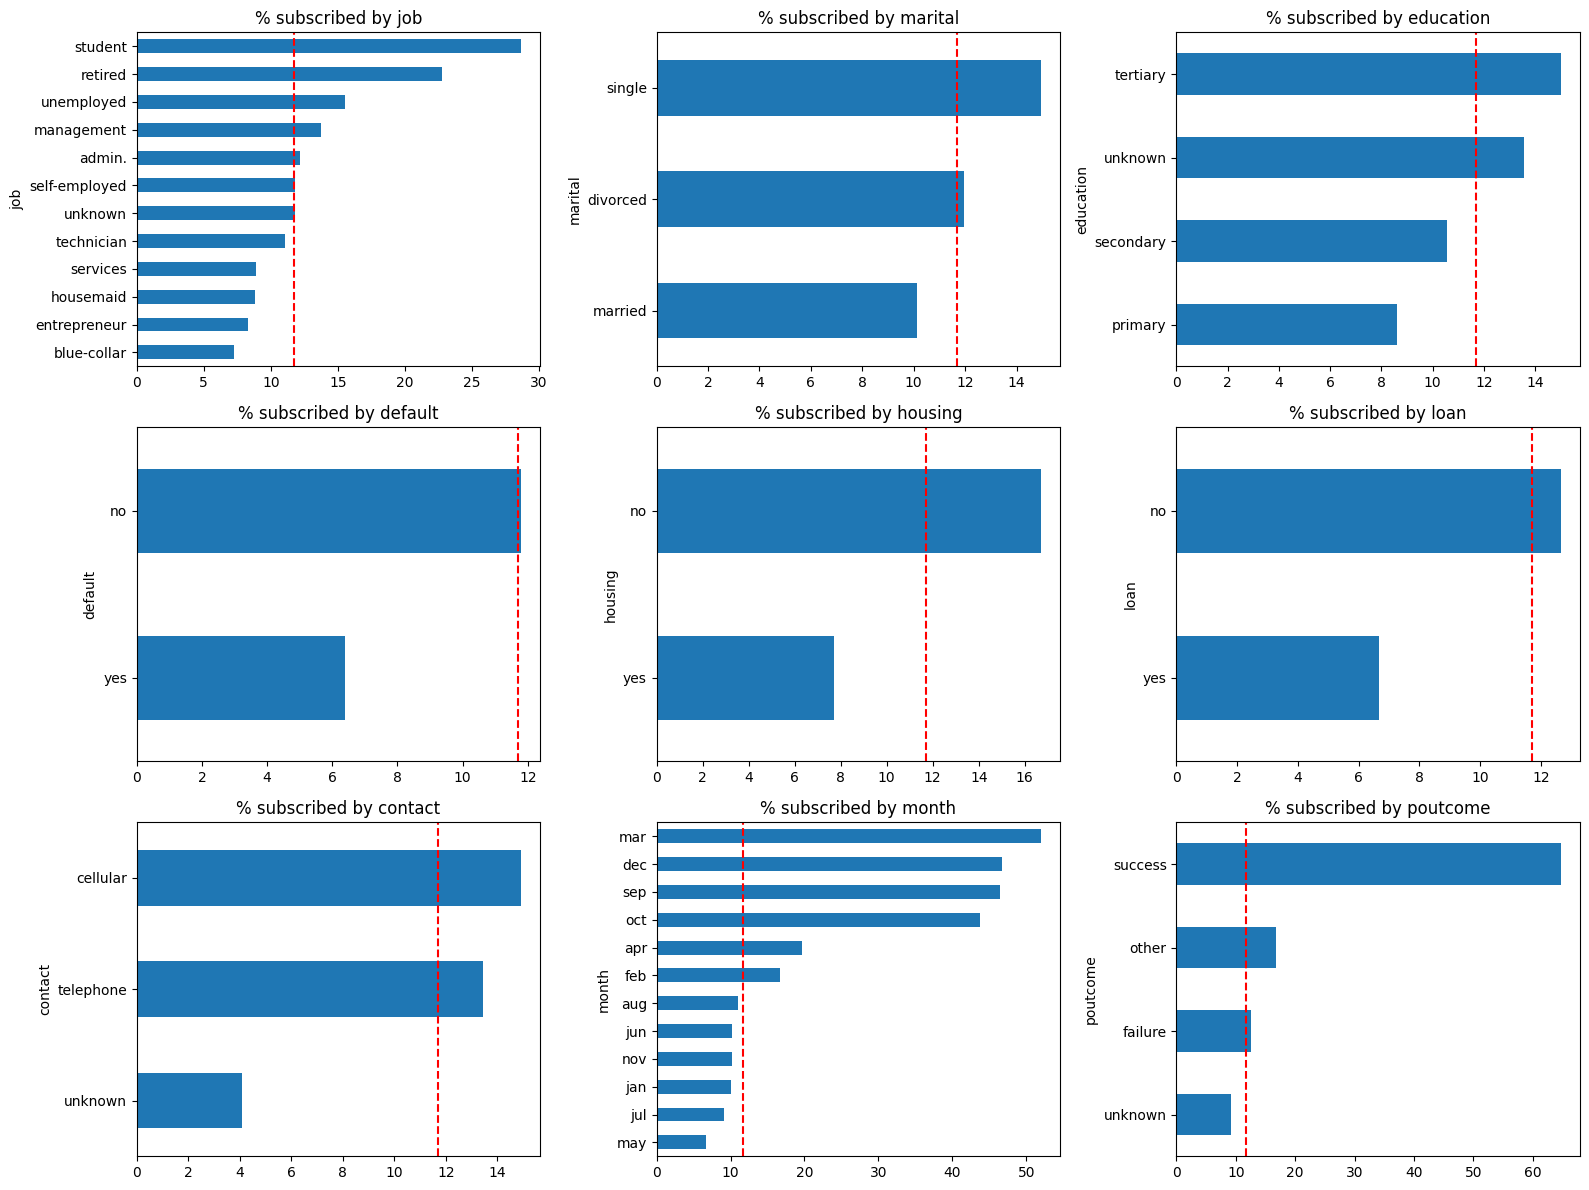

In [19]:
cat_cols = ["job", "marital", "education", "default", "housing",
            "loan", "contact", "month", "poutcome"]
overall = df["y"].mean() * 100

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)["y"].mean().mul(100).sort_values()
    rate.plot.barh(ax=ax)
    ax.axvline(overall, color="red", linestyle="--")   # red line = overall 11.7%
    ax.set_title(f"% subscribed by {col}")
plt.tight_layout()
save_fig("2.2-subscription-rate-by-category.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

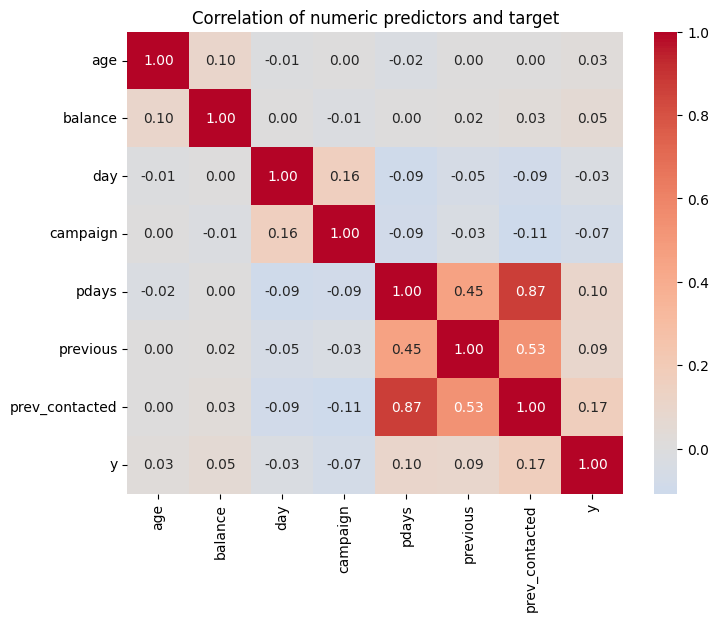

In [20]:
corr = df[num_cols + ["prev_contacted", "y"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of numeric predictors and target")
save_fig("2.3-correlation-heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

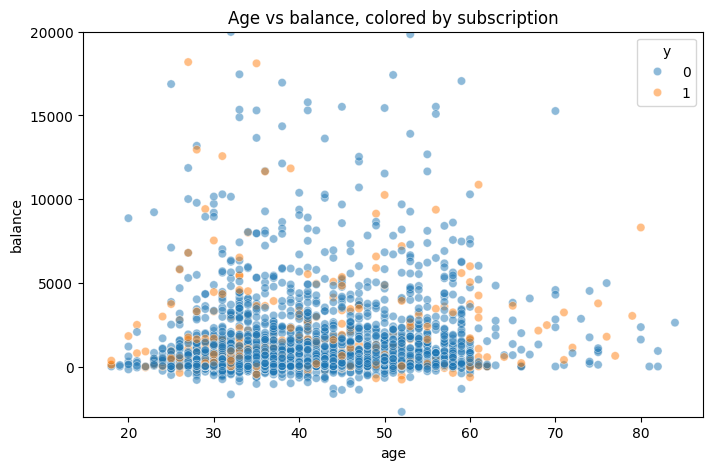

In [22]:
sample = df.sample(3000, random_state=42)   # 3,000 points so the plot stays readable
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="age", y="balance", hue="y", alpha=0.5)
plt.ylim(-3000, 20000)                      # trim extreme balances for visibility
plt.title("Age vs balance, colored by subscription")
save_fig("2.4-age-balance-scatter.png")